# 03 — Preprocesamiento de TACO Play

Este notebook prepara TACO Play para el entrenamiento posterior de un modelo Vision-Language-Action (VLA). El flujo mantiene las vistas `static` y `gripper` como referencias a sus vídeos, tokeniza las instrucciones con CLIP y normaliza las acciones continuas.

## 1. Configuración e imports

Se reutiliza CLIP ViT-B/32 y su transformación `preprocess`, cuya disponibilidad se comprobó en el notebook 01. El entorno actual utiliza CPU, por lo que se mantendrá un tamaño de lote reducido.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

import sys
import os
notebook_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.clip_encoder import CLIPEncoder
from src.dataset import VLADataset, cargar_fotograma, mapear_indices_globales
from src.project_config import PROJECT_DIR, taco_play_dir, ensure_project_dirs

# Ruta local del dataset descargado en el notebook 02.
RUTA = taco_play_dir()
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEMILLA = 42

# Se carga el mismo encoder visual y el mismo preprocesado comprobados previamente.
encoder_clip = CLIPEncoder("ViT-B-32", "openai", DISPOSITIVO, congelar=True)
preprocess = encoder_clip.preprocess
tokenizer = encoder_clip.tokenizer

print(f"Dispositivo: {DISPOSITIVO}")
print(f"Ruta del dataset: {RUTA}")
# Rutas compartidas: no dependen del directorio desde el que se abra el notebook.
ROOT_DIR = PROJECT_DIR
ensure_project_dirs()
RUTA = taco_play_dir()


c:\TFM_Codigo\TFM-VLA\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Dispositivo: cpu
Ruta del dataset: E:\TFM_datasets\taco_play_lerobot


## 2. Carga y preparación de los datos

Se cargan los registros tabulares y los metadatos de episodios. Cada muestra conserva la instrucción, acción, episodio y fotograma; las columnas de `static` y `gripper` contienen las rutas y los fotogramas locales que permiten recuperar ambas imágenes bajo demanda.

Los MP4 agrupan varios episodios y sus timestamps no siempre coinciden con el número físico de frames. Por ello, cada muestra se localiza mediante su `index` global y los límites reales de los vídeos, guardando para `static` y `gripper` la ruta del MP4 y el frame local resultante.

In [2]:
tareas = pd.read_parquet(RUTA / "meta" / "tasks.parquet")
mapa_tareas = dict(zip(tareas["task_index"], tareas.index))

archivos_datos = sorted((RUTA / "data").rglob("*.parquet"))
datos = pd.concat(
    [
        pd.read_parquet(
            archivo,
            columns=["action", "next.done", "episode_index", "frame_index", "index", "task_index"]
        )
        for archivo in archivos_datos
    ],
    ignore_index=True
)

datos["accion"] = list(np.column_stack((
    datos["next.done"].to_numpy(dtype=np.float32),
    np.vstack(datos["action"].to_numpy()).astype(np.float32),
)))

# El índice global se asigna a los MP4 de cada cámara según sus límites físicos.
rutas_static, frames_static = mapear_indices_globales(
    datos["index"].to_numpy(),
    RUTA / "videos" / "observation.images.rgb_static",
)
rutas_gripper, frames_gripper = mapear_indices_globales(
    datos["index"].to_numpy(),
    RUTA / "videos" / "observation.images.rgb_gripper",
)
muestras = datos.copy()
muestras["instruccion"] = muestras["task_index"].map(mapa_tareas)
muestras["imagen_static"] = rutas_static
muestras["fotograma_static"] = frames_static
muestras["imagen_gripper"] = rutas_gripper
muestras["fotograma_gripper"] = frames_gripper


tabla_final = muestras[[
    "imagen_static", "fotograma_static", "imagen_gripper", "fotograma_gripper",
    "instruccion", "accion",
    "episode_index", "frame_index", "index", "task_index"
]]

print(f"Muestras cargadas: {len(tabla_final):,}")
print(f"Episodios: {tabla_final['episode_index'].nunique():,}")
display(tabla_final.head())

Muestras cargadas: 237,798
Episodios: 3,603


,imagen_static,fotograma_static,imagen_gripper,fotograma_gripper,instruccion,accion,episode_index,frame_index,index,task_index
0,E:\TFM_datasets\taco_play_lerobot\videos\obser...,0,E:\TFM_datasets\taco_play_lerobot\videos\obser...,0,rotate the yellow block to the left,"[0.0, 0.10251923, 0.104787074, -0.25172234, -0...",0,0,0,0
1,E:\TFM_datasets\taco_play_lerobot\videos\obser...,1,E:\TFM_datasets\taco_play_lerobot\videos\obser...,1,rotate the yellow block to the left,"[0.0, 0.12426677, 0.044257797, -0.23885965, -0...",0,1,1,0
2,E:\TFM_datasets\taco_play_lerobot\videos\obser...,2,E:\TFM_datasets\taco_play_lerobot\videos\obser...,2,rotate the yellow block to the left,"[0.0, 0.08845188, 0.02940148, -0.15476942, -0....",0,2,2,0
3,E:\TFM_datasets\taco_play_lerobot\videos\obser...,3,E:\TFM_datasets\taco_play_lerobot\videos\obser...,3,rotate the yellow block to the left,"[0.0, 0.20840426, 0.054982908, -0.19856691, 0....",0,3,3,0
4,E:\TFM_datasets\taco_play_lerobot\videos\obser...,4,E:\TFM_datasets\taco_play_lerobot\videos\obser...,4,rotate the yellow block to the left,"[0.0, 0.26733512, 0.04810836, -0.096565485, -0...",0,4,4,0


## 3. Preprocesamiento de imágenes

Se recuperan las dos imágenes de un mismo ejemplo desde sus vídeos y se aplica `preprocess` a cada una. Los tensores resultantes quedan preparados para el encoder visual ViT de CLIP, sin calcular todavía sus embeddings.

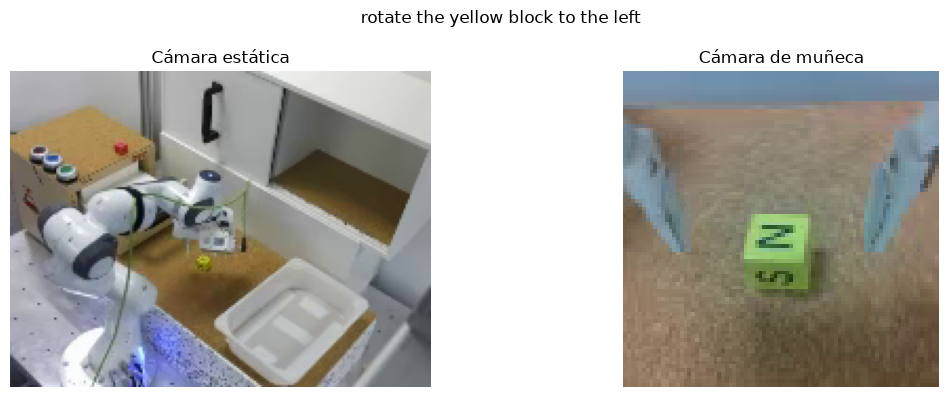

Tamaño static: (200, 150) | Tensor CLIP: torch.Size([3, 224, 224])
Tamaño gripper: (84, 84) | Tensor CLIP: torch.Size([3, 224, 224])


In [3]:
ejemplo = tabla_final.iloc[0]
imagen_static = cargar_fotograma(ejemplo["imagen_static"], ejemplo["fotograma_static"])
imagen_gripper = cargar_fotograma(ejemplo["imagen_gripper"], ejemplo["fotograma_gripper"])
tensor_static = preprocess(imagen_static)
tensor_gripper = preprocess(imagen_gripper)

figura, ejes = plt.subplots(1, 2, figsize=(12, 4))
for eje, nombre, imagen in zip(ejes, ["Cámara estática", "Cámara de muñeca"], [imagen_static, imagen_gripper]):
    eje.imshow(imagen)
    eje.set_title(nombre)
    eje.axis("off")
figura.suptitle(ejemplo["instruccion"])
plt.tight_layout()
plt.show()

print(f"Tamaño static: {imagen_static.size} | Tensor CLIP: {tensor_static.shape}")
print(f"Tamaño gripper: {imagen_gripper.size} | Tensor CLIP: {tensor_gripper.shape}")
assert tensor_static.shape == tensor_gripper.shape
assert tensor_static.dtype == tensor_gripper.dtype

## 4. Procesamiento de instrucciones con CLIP

Las instrucciones asociadas a cada `task_index` se tokenizan con el tokenizer de CLIP. En esta etapa solo se preparan los tokens; los embeddings textuales se generarán cuando el modelo los necesite.

In [4]:
instruccion_ejemplo = ejemplo["instruccion"]
tokens_ejemplo = tokenizer([instruccion_ejemplo])

print(f"Instrucción: {instruccion_ejemplo}")
print(f"Longitud máxima del tokenizer: {tokens_ejemplo.shape[1]}")
print(f"Dimensiones de los tokens: {tokens_ejemplo.shape}")
print(f"Tipo de los tokens: {tokens_ejemplo.dtype}")

Instrucción: rotate the yellow block to the left
Longitud máxima del tokenizer: 77
Dimensiones de los tokens: torch.Size([1, 77])
Tipo de los tokens: torch.int64


## 5. Representación y criterios de pérdida de las acciones

Cada acción tiene ocho componentes: `[terminate, x, y, z, rx, ry, rz, gripper]`. `terminate` usa BCE. La pinza adopta BCE y métricas de clasificación solo si la comprobación del notebook 02 confirma que sus valores son estrictamente binarios; las seis componentes físicas usan MSE.

In [5]:
NOMBRES_ACCION = ["terminate", "x", "y", "z", "rx", "ry", "rz", "gripper"]
PINZA_BINARIA = True  # Confirmado en el notebook 02 para TACO Play.
print(NOMBRES_ACCION)
print("Pérdida: MSE(x..rz) + BCE(terminate) + BCE(gripper binaria)")


['terminate', 'x', 'y', 'z', 'rx', 'ry', 'rz', 'gripper']
Pérdida: MSE(x..rz) + BCE(terminate) + BCE(gripper binaria)


La primera dimension, `terminate`, se construye explicitamente a partir de `next.done`: el booleano se convierte a `0.0` o `1.0` y se antepone al vector original de siete componentes. Asi, `terminate = 1.0` solo en el ultimo frame del episodio y cada accion queda como `[terminate, x, y, z, rx, ry, rz, gripper]`.

## 6. División Train / Validation / Test

La división se realiza por episodios completos y no por fotogramas. De este modo, ningún frame de un mismo episodio puede aparecer en más de una partición, evitando fuga de información entre entrenamiento y evaluación.

In [6]:
PROPORCION_TRAIN = 0.80
PROPORCION_VALIDATION = 0.10
PROPORCION_TEST = 0.10

assert np.isclose(PROPORCION_TRAIN + PROPORCION_VALIDATION + PROPORCION_TEST, 1.0)

generador = np.random.default_rng(SEMILLA)
episodios_unicos = tabla_final["episode_index"].drop_duplicates().to_numpy().copy()
generador.shuffle(episodios_unicos)

n_episodios = len(episodios_unicos)
limite_train = int(PROPORCION_TRAIN * n_episodios)
limite_val = limite_train + int(PROPORCION_VALIDATION * n_episodios)

episodios_train = set(episodios_unicos[:limite_train])
episodios_val = set(episodios_unicos[limite_train:limite_val])
episodios_test = set(episodios_unicos[limite_val:])

train = tabla_final[tabla_final["episode_index"].isin(episodios_train)].reset_index(drop=True)
validation = tabla_final[tabla_final["episode_index"].isin(episodios_val)].reset_index(drop=True)
test = tabla_final[tabla_final["episode_index"].isin(episodios_test)].reset_index(drop=True)

assert episodios_train.isdisjoint(episodios_val)
assert episodios_train.isdisjoint(episodios_test)
assert episodios_val.isdisjoint(episodios_test)

resumen_particiones = pd.DataFrame({
    "partición": ["train", "validation", "test"],
    "episodios": [len(episodios_train), len(episodios_val), len(episodios_test)],
    "muestras": [len(train), len(validation), len(test)],
})
display(resumen_particiones)

# Los parámetros se estiman solo con train para poder desnormalizar sin fuga de información.
acciones_train = np.vstack(train["accion"].to_numpy()).astype(np.float32)
minimo_accion = acciones_train.min(axis=0)
maximo_accion = acciones_train.max(axis=0)
escala_accion = np.where(maximo_accion - minimo_accion == 0, 1.0, maximo_accion - minimo_accion)
parametros_normalizacion = {
    "minimo": minimo_accion,
    "maximo": maximo_accion,
    "escala": escala_accion,
}
ROOT_DIR = Path(os.getcwd()).resolve().parent
ruta_parametros = ROOT_DIR / "data" / "parametros_normalizacion.json"
ruta_parametros.parent.mkdir(parents=True, exist_ok=True)
ruta_parametros.write_text(
    json.dumps({clave: valor.tolist() for clave, valor in parametros_normalizacion.items()}, indent=2),
    encoding="utf-8",
)

def normalizar_accion(accion):
    """Escala una acción continua con los rangos de entrenamiento."""
    return (np.asarray(accion, dtype=np.float32) - minimo_accion) / escala_accion

def desnormalizar_accion(accion_normalizada):
    """Recupera la escala original de una acción normalizada."""
    return np.asarray(accion_normalizada, dtype=np.float32) * escala_accion + minimo_accion

accion_normalizada_ejemplo = normalizar_accion(train.loc[0, "accion"])
assert np.allclose(
    train.loc[0, "accion"],
    desnormalizar_accion(accion_normalizada_ejemplo),
    atol=1e-6
)
print(f"Parámetros de normalización guardados en {ruta_parametros} y comprobados.")

,partición,episodios,muestras
0,train,2882,190212
1,validation,360,23760
2,test,361,23826


Parámetros de normalización guardados en C:\TFM_Codigo\TFM-VLA\data\parametros_normalizacion.json y comprobados.


### 6.1 Persistencia de las particiones definitivas

Las tres tablas se guardan antes de normalizar. Conservan las referencias `static` y `gripper`, junto con los identificadores de episodio, fotograma, tarea e índice de muestra original, para que el notebook 04 pueda reutilizarlas sin reconstruir ni volver a dividir los datos.

In [7]:
RUTA_PROCESADO = ROOT_DIR / "data" / "procesado_clip"
RUTA_PROCESADO.mkdir(parents=True, exist_ok=True)
particiones_definitivas = {"train": train, "validation": validation, "test": test}
columnas_identificadores = {"episode_index", "frame_index", "task_index", "index"}
for nombre, particion in particiones_definitivas.items():
    assert columnas_identificadores.issubset(particion.columns)
    particion.to_parquet(RUTA_PROCESADO / f"{nombre}.parquet", index=False)
    print(f"{nombre}: {len(particion):,} muestras guardadas en {RUTA_PROCESADO / f'{nombre}.parquet'}")


train: 190,212 muestras guardadas en C:\TFM_Codigo\TFM-VLA\data\procesado_clip\train.parquet
validation: 23,760 muestras guardadas en C:\TFM_Codigo\TFM-VLA\data\procesado_clip\validation.parquet
test: 23,826 muestras guardadas en C:\TFM_Codigo\TFM-VLA\data\procesado_clip\test.parquet


## 7. Creación del `Dataset`

`VLADataset` carga los fotogramas `static` y `gripper` solo cuando se solicitan, aplica el preprocesamiento de CLIP a ambos y devuelve la instrucción tokenizada junto con la acción normalizada. Esto mantiene el uso de memoria contenido en CPU.

In [8]:
train_normalizado = train.copy()
validation_normalizado = validation.copy()
test_normalizado = test.copy()
for tabla_normalizada in (train_normalizado, validation_normalizado, test_normalizado):
    tabla_normalizada["accion"] = tabla_normalizada["accion"].apply(normalizar_accion)

train_dataset = VLADataset(train_normalizado, preprocess, tokenizer)
val_dataset = VLADataset(validation_normalizado, preprocess, tokenizer)
test_dataset = VLADataset(test_normalizado, preprocess, tokenizer)

print(f"Muestras en train_dataset: {len(train_dataset):,}")

Muestras en train_dataset: 190,212


## 8. Creación de los `DataLoader`

Se utiliza un lote pequeño y `num_workers=0` para mantener el pipeline ligero y compatible con el entorno actual de CPU sin CUDA.

In [9]:
BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batch size: {BATCH_SIZE}")
print(f"Batches de entrenamiento: {len(train_loader):,}")

Batch size: 4
Batches de entrenamiento: 47,553


## 9. Comprobación final del pipeline

La siguiente prueba recorre una única vez el flujo completo `Dataset → DataLoader → batch` y comprueba las dimensiones de las dos vistas que recibirá el modelo.

In [10]:
imagenes_static_batch, imagenes_gripper_batch, tokens_batch, acciones_batch = next(iter(train_loader))

print(f"Shape de las imágenes static: {imagenes_static_batch.shape}")
print(f"Shape de las imágenes gripper: {imagenes_gripper_batch.shape}")
print(f"Shape de los tokens: {tokens_batch.shape}")
print(f"Shape de las acciones: {acciones_batch.shape}")
assert imagenes_static_batch.shape == imagenes_gripper_batch.shape
assert acciones_batch.shape[1] == 8
print("Pipeline de preprocesamiento preparado correctamente.")

Shape de las imágenes static: torch.Size([4, 3, 224, 224])
Shape de las imágenes gripper: torch.Size([4, 3, 224, 224])
Shape de los tokens: torch.Size([4, 77])
Shape de las acciones: torch.Size([4, 8])
Pipeline de preprocesamiento preparado correctamente.


## Resumen de resultados

Este notebook utiliza la configuración centralizada, crea las particiones con las vistas `static` y `gripper`, y deja los artefactos del experimento preparados para el notebook 04.